<a href="https://colab.research.google.com/github/firstsignal/activation-geometry-sentiment/blob/main/activation_space_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install transformer-lens

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 4.0 MB/s eta 0:00:00


In [ ]:
from transformer_lens import HookedTransformer

model = HookedTransformer.from_pretrained('pythia-70m')

print('Model loaded!')

config.json:   0%|          | 0.00/567 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/166M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/396 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

Loaded pretrained model pythia-70m into HookedTransformer
Model loaded!


In [ ]:
import torch

# Small labelled set. Keep sentences short and clearly polarised for v1.
positive = [
    "I love this, it is wonderful and makes me so happy.",
    "This is fantastic, absolutely delightful and brilliant.",
    "What a joyful, beautiful, amazing day this has been.",
    "I feel great, everything is going perfectly and I am thrilled.",
    "That was excellent, truly the best experience of my life.",
]
negative = [
    "I hate this, it is awful and makes me so miserable.",
    "This is terrible, absolutely disgusting and dreadful.",
    "What a bleak, ugly, horrible day this has been.",
    "I feel awful, everything is going wrong and I am furious.",
    "That was dreadful, truly the worst experience of my life.",
]

LAYER = 3  # a middle-ish layer for a 6-layer model; we can sweep later

def get_resid(prompts):
    vecs = []
    for p in prompts:
        tokens = model.to_tokens(p)
        _, cache = model.run_with_cache(tokens)
        # residual stream at LAYER, mean over sequence positions
        act = cache["resid_post", LAYER][0].mean(dim=0)
        vecs.append(act)
    return torch.stack(vecs)

pos_acts = get_resid(positive)
neg_acts = get_resid(negative)

print("pos_acts shape:", pos_acts.shape)
print("neg_acts shape:", neg_acts.shape)


pos_acts shape: torch.Size([5, 512])
neg_acts shape: torch.Size([5, 512])


In [ ]:
# Difference-of-means: the sentiment axis
pos_mean = pos_acts.mean(dim=0)
neg_mean = neg_acts.mean(dim=0)
sentiment_dir = pos_mean - neg_mean
sentiment_dir = sentiment_dir / sentiment_dir.norm()  # unit vector

# Project every training sentence onto the axis
def project(acts, direction):
    return acts @ direction

pos_proj = project(pos_acts, sentiment_dir)
neg_proj = project(neg_acts, sentiment_dir)

print("positive projections:", [round(x.item(), 2) for x in pos_proj])
print("negative projections:", [round(x.item(), 2) for x in neg_proj])

# --- CONTROL: a random direction should NOT separate them ---
torch.manual_seed(0)
random_dir = torch.randn(512)
random_dir = random_dir / random_dir.norm()

pos_ctrl = project(pos_acts, random_dir)
neg_ctrl = project(neg_acts, random_dir)

print("\n--- control (random direction) ---")
print("positive:", [round(x.item(), 2) for x in pos_ctrl])
print("negative:", [round(x.item(), 2) for x in neg_ctrl])


positive projections: [-1.84, -2.0, -2.06, -2.15, -1.77]
negative projections: [-4.16, -4.84, -4.46, -4.14, -4.43]

--- control (random direction) ---
positive: [0.14, 0.2, 0.39, 0.15, 0.3]
negative: [0.24, 0.33, 0.64, 0.15, 0.42]


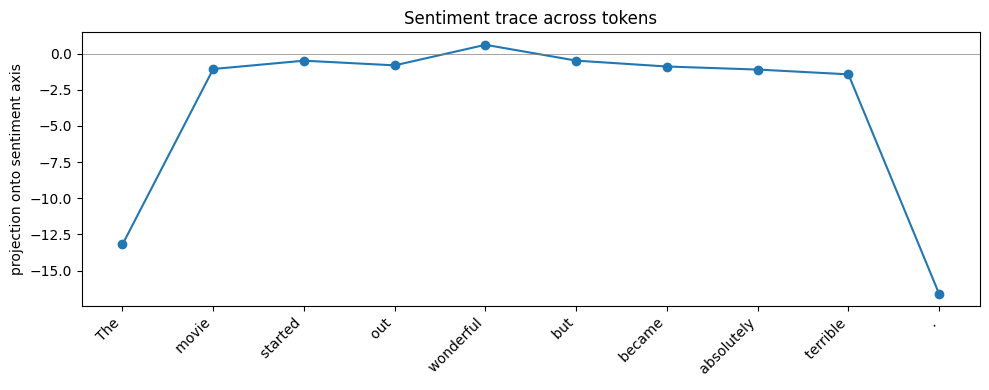

In [ ]:
import matplotlib.pyplot as plt

test_sentence = "The movie started out wonderful but became absolutely terrible."

tokens = model.to_tokens(test_sentence)
_, cache = model.run_with_cache(tokens)
resid = cache["resid_post", LAYER][0]          # [seq, 512]
trace = resid @ sentiment_dir                   # project each token

str_tokens = model.to_str_tokens(test_sentence)

plt.figure(figsize=(10, 4))
plt.plot(range(len(trace)), trace.detach().numpy(), marker="o")
plt.xticks(range(len(str_tokens)), str_tokens, rotation=45, ha="right")
plt.axhline(0, color="gray", linewidth=0.5)
plt.ylabel("projection onto sentiment axis")
plt.title("Sentiment trace across tokens")
plt.tight_layout()
plt.show()


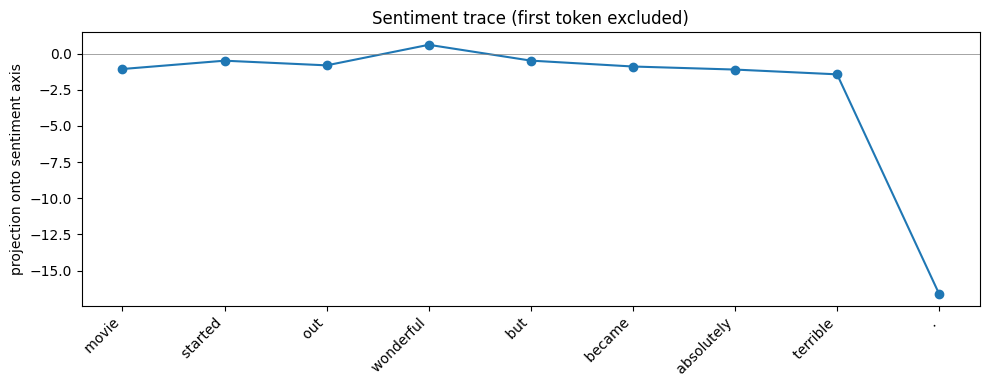

In [ ]:
# Re-plot excluding the first (BOS/sink) token, which dominates the scale
import matplotlib.pyplot as plt

trace_np = trace.detach().numpy()
plt.figure(figsize=(10, 4))
plt.plot(range(1, len(trace_np)), trace_np[1:], marker="o")
plt.xticks(range(1, len(str_tokens)), str_tokens[1:], rotation=45, ha="right")
plt.axhline(0, color="gray", linewidth=0.5)
plt.ylabel("projection onto sentiment axis")
plt.title("Sentiment trace (first token excluded)")
plt.tight_layout()
plt.show()
